In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import tensorflow as tf

In [18]:
DATASET_PATH = r'C:\Users\ameth\Desktop\pruebas\archive'

METADATA_PATH = os.path.join(
    DATASET_PATH,
    "UrbanSound8K.csv"
)

metadata = pd.read_csv(METADATA_PATH)

### ANALISIS EXPLORATORIO

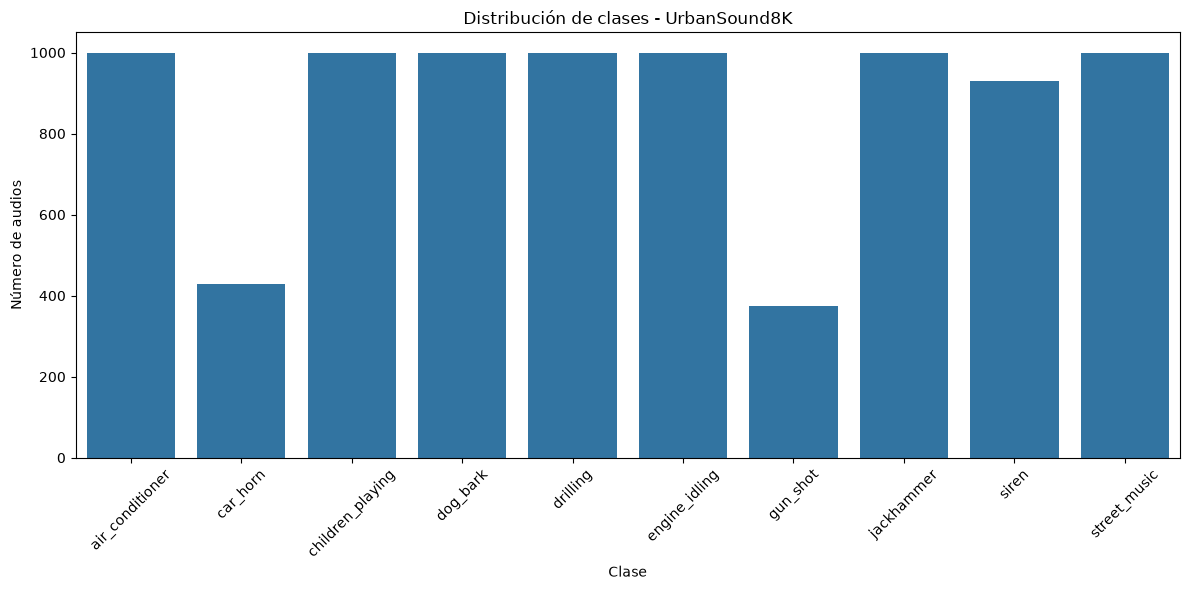

In [19]:
# --------------------------------------------
# Distribución de clases
# --------------------------------------------

class_counts = metadata["class"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Distribución de clases - UrbanSound8K")
plt.xlabel("Clase")
plt.ylabel("Número de audios")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

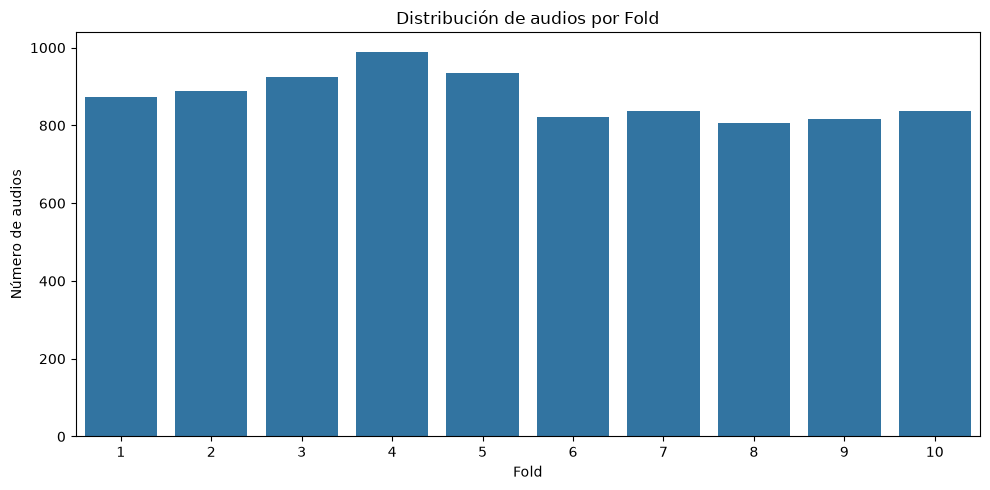

In [20]:
# --------------------------------------------
# Distribución de audios por Fold
# --------------------------------------------

fold_counts = metadata["fold"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=fold_counts.index.astype(str),
    y=fold_counts.values
)

plt.title("Distribución de audios por Fold")
plt.xlabel("Fold")
plt.ylabel("Número de audios")
plt.tight_layout()
plt.show()

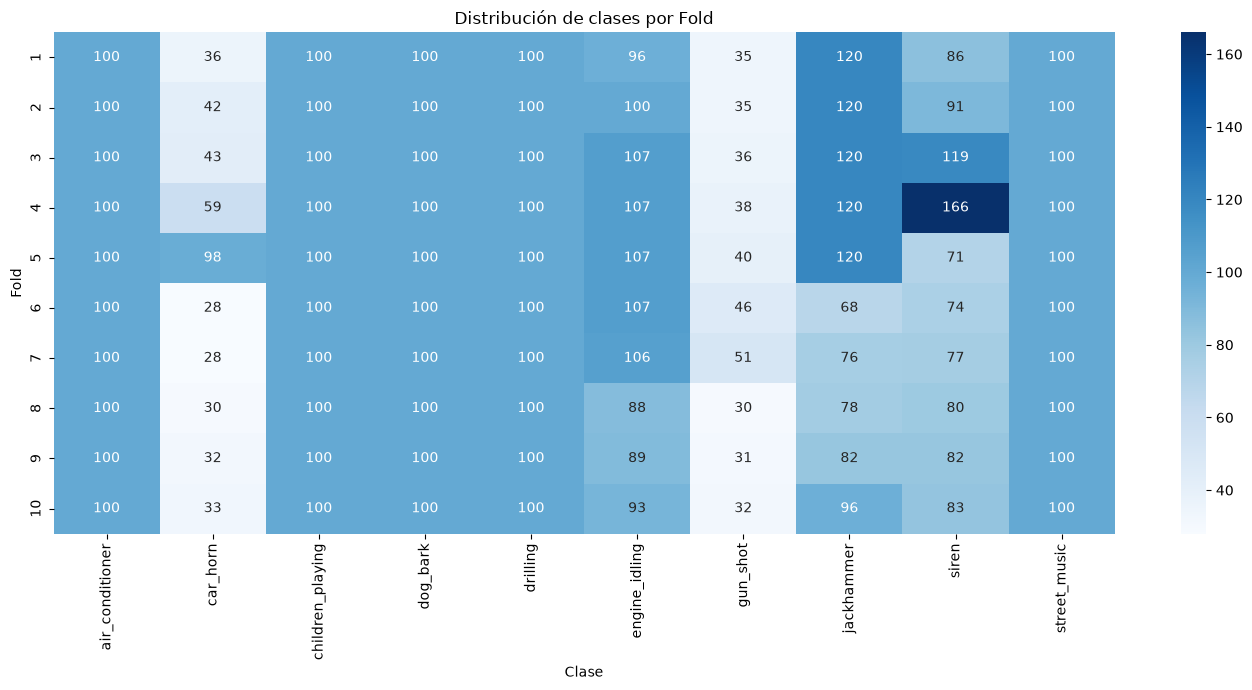

In [21]:
# --------------------------------------------
# Distribución de clases por Fold
# --------------------------------------------

fold_class_counts = pd.crosstab(
    metadata["fold"],
    metadata["class"]
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    fold_class_counts,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Distribución de clases por Fold")
plt.xlabel("Clase")
plt.ylabel("Fold")
plt.tight_layout()
plt.show()

In [ ]:
# Resumen del dataset

print("Número total de audios:", len(metadata))
print("Número de clases:", metadata["class"].nunique())
print("Número de folds:", metadata["fold"].nunique())

print("\nClases:")
print(sorted(metadata["class"].unique()))

print("\nCantidad por clase:")
print(metadata["class"].value_counts().sort_index())

print("\nCantidad por Fold:")
print(metadata["fold"].value_counts().sort_index())

Número total de audios: 8732
Número de clases: 10
Número de folds: 10

Clases:
['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']

Cantidad por clase:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Cantidad por Fold:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


### LECTURA DE FOLDS

In [23]:
def get_audio_path(row):
    return os.path.join(
        DATASET_PATH,
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

metadata["audio_path"] = metadata.apply(
    get_audio_path,
    axis=1
)

#VALIDACION

metadata["file_exists"] = metadata["audio_path"].apply(
    os.path.isfile
)

print("\nComprobación de archivos:")

print(
    metadata["file_exists"].value_counts()
)


Comprobación de archivos:
file_exists
True    8732
Name: count, dtype: int64


### CONVERTIR ARCHIVOS A MEL - ESPECTROGRAMA

Archivo: 100032-3-0-0.wav
Clase: dog_bark
Fold: 5


c:\Users\ameth\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate: 44100
Duración: 0.318 segundos


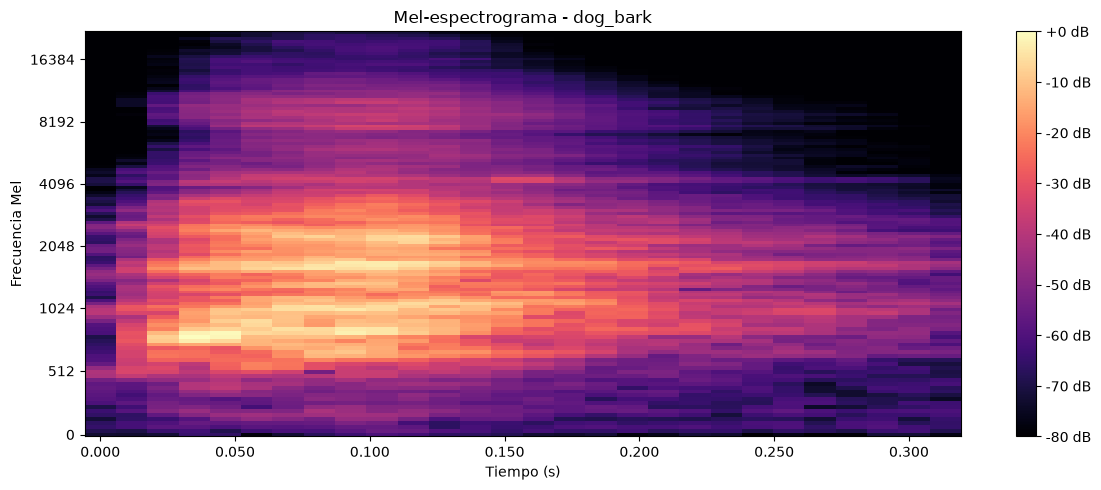

Dimensiones del Mel-espectrograma:
(128, 28)

Valor máximo: 0.0
Valor mínimo: -80.0


In [24]:
sample = metadata[
    metadata["file_exists"]
].iloc[0]

audio_path = sample["audio_path"]

print("Archivo:", sample["slice_file_name"])
print("Clase:", sample["class"])
print("Fold:", sample["fold"])

audio, sample_rate = librosa.load(
    audio_path,
    sr=None
)

print("Sample rate:", sample_rate)
print(
    "Duración:",
    round(len(audio) / sample_rate, 3),
    "segundos"
)

mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sample_rate,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"Mel-espectrograma - {sample['class']}"
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia Mel")

plt.tight_layout()
plt.show()

print("Dimensiones del Mel-espectrograma:")
print(mel_db.shape)

print("\nValor máximo:", mel_db.max())
print("Valor mínimo:", mel_db.min())

Clase: dog_bark
Fold: 5
Dimensiones: (128, 173)


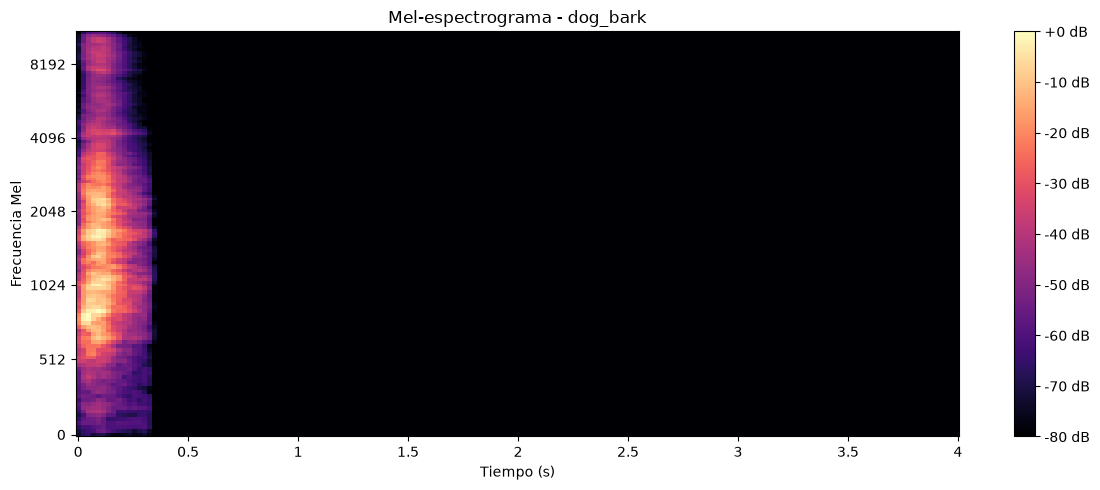

In [25]:
# Parámetros del procesamiento
SAMPLE_RATE = 22050
DURATION = 4
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

# Número de muestras correspondientes a 4 segundos
NUM_SAMPLES = SAMPLE_RATE * DURATION


# FUNCIÓN AUDIO → MEL-ESPECTROGRAMA

def audio_to_mel(audio_path):

    # Cargar el audio y convertirlo a 22050 Hz
    audio, sr = librosa.load(
        audio_path,
        sr=SAMPLE_RATE,
        duration=DURATION
    )

    # Completar con ceros los audios menores de 4 segundos
    if len(audio) < NUM_SAMPLES:
        audio = np.pad(
            audio,
            (0, NUM_SAMPLES - len(audio))
        )

    # Recortar los audios que superen los 4 segundos
    else:
        audio = audio[:NUM_SAMPLES]

    # Convertir el audio en Mel-espectrograma
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Convertir la potencia a escala logarítmica de decibeles
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db


# TEST

test_mel = audio_to_mel(
    sample["audio_path"]
)

print("Clase:", sample["class"])
print("Fold:", sample["fold"])
print("Dimensiones:", test_mel.shape)



plt.figure(figsize=(12, 5))

librosa.display.specshow(
    test_mel,
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(
    format="%+2.0f dB"
)

plt.title(
    f"Mel-espectrograma - {sample['class']}"
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Frecuencia Mel")

plt.tight_layout()
plt.show()

### DIVISION TRAIN - VALIDATION - TEST

In [26]:
train_df = metadata[
    metadata["fold"].between(1, 8)
].copy()

val_df = metadata[
    metadata["fold"] == 9
].copy()

test_df = metadata[
    metadata["fold"] == 10
].copy()

X_train = train_df["audio_path"].values
X_val = val_df["audio_path"].values
X_test = test_df["audio_path"].values

y_train = train_df["classID"].values
y_val = val_df["classID"].values
y_test = test_df["classID"].values

class_names = (
    metadata[["classID", "class"]]
    .drop_duplicates()
    .sort_values("classID")
)

class_names = class_names["class"].values


print("Número de muestras:")
print("-------------------")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nNúmero total:", len(X_train) + len(X_val) + len(X_test))

print("\nClases:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Número de muestras:
-------------------
Train: 7079
Validation: 816
Test: 837

Número total: 8732

Clases:
0: air_conditioner
1: car_horn
2: children_playing
3: dog_bark
4: drilling
5: engine_idling
6: gun_shot
7: jackhammer
8: siren
9: street_music


### GENERACION DE MEL - ESPECTROGRAMA

In [27]:
def create_mel_dataset(audio_paths, labels):

    X = []
    y = []

    for audio_path, label in zip(audio_paths, labels):

        mel = audio_to_mel(audio_path)

        # Añadir dimensión del canal
        mel = mel[..., np.newaxis]

        X.append(mel)
        y.append(label)

    return np.array(X, dtype=np.float32), np.array(y)

#TRAIN
X_train_mel, y_train = create_mel_dataset(
    X_train,
    y_train
)

#VALIDACION
X_val_mel, y_val = create_mel_dataset(
    X_val,
    y_val
)

#TEST
X_test_mel, y_test = create_mel_dataset(
    X_test,
    y_test
)

print("Train:", X_train_mel.shape)
print("Validation:", X_val_mel.shape)
print("Test:", X_test_mel.shape)

Train: (7079, 128, 173, 1)
Validation: (816, 128, 173, 1)
Test: (837, 128, 173, 1)


### CNN BASELINE

In [29]:
cnn_model = models.Sequential([

    # Primera capa
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 173, 1)
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Segunda capa
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Tercera capa
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convertir las características en un vector
    layers.Flatten(),

    # Capa completamente conectada
    layers.Dense(
        256,
        activation="relu"
    ),

    # Reducir el sobreajuste
    layers.Dropout(
        0.5
    ),

    # Clasificación de las 10 clases
    layers.Dense(
        10,
        activation="softmax"
    )
])



# Compilar el modelo


cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



# Mostrar arquitectura

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 171, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 83, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 41, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 34048)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,716,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,811,786 (33.61 MB)

 Trainable params: 8,811,786 (33.61 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
BATCH_SIZE = 32
EPOCHS = 30



# Early Stopping


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)



#  Guarda el mejor modelo


checkpoint = ModelCheckpoint(
    "cnn_baseline_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)



#  Entrenar la CNN


history_cnn = cnn_model.fit(
    X_train_mel,
    y_train,
    validation_data=(
        X_val_mel,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.1195 - loss: 2.9263
Epoch 1: val_loss improved from None to 2.24667, saving model to cnn_baseline_best.keras

Epoch 1: finished saving model to cnn_baseline_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 64s 279ms/step - accuracy: 0.1195 - loss: 2.9263 - val_accuracy: 0.1238 - val_loss: 2.2467
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.1389 - loss: 2.3074
Epoch 2: val_loss did not improve from 2.24667
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.1389 - loss: 2.3074 - val_accuracy: 0.1225 - val_loss: 2.2501
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.1136 - loss: 2.3106
Epoch 3: val_loss did not improve from 2.24667
222/222 ━━━━━━━━━━━━━━━━━━━━ 59s 264ms/step - accuracy: 0.1136 - loss: 2.3106 - val_accuracy: 0.1091 - val_loss: 2.2493
Epoch 4/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.1089 - loss: 2.2638
Epoch 4: val_loss did not improve from 2.24667

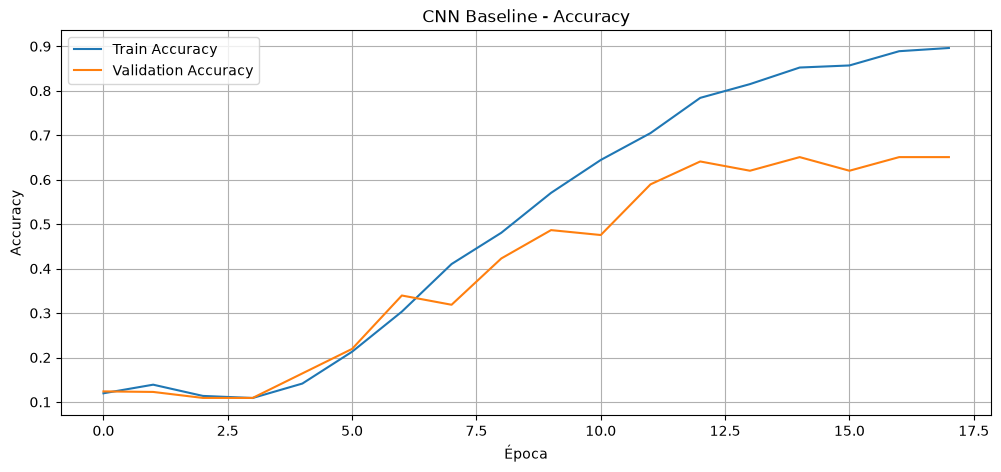

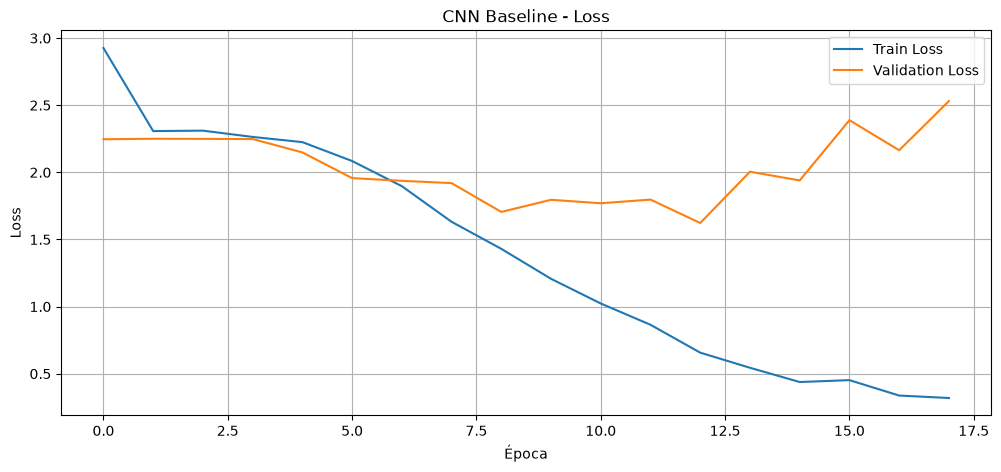

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Baseline - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Baseline - Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step
RESULTADOS CNN BASELINE - FOLD 10
-----------------------------------
Accuracy : 0.6619
Precision: 0.6765
Recall   : 0.6619
F1-score : 0.6604

REPORTE POR CLASE
-----------------
                  precision    recall  f1-score   support

 air_conditioner       0.73      0.76      0.75       100
        car_horn       0.93      0.76      0.83        33
children_playing       0.46      0.65      0.54       100
        dog_bark       0.78      0.76      0.77       100
        drilling       0.58      0.53      0.55       100
   engine_idling       0.57      0.47      0.52        93
        gun_shot       0.81      0.81      0.81        32
      jackhammer       0.66      0.92      0.77        96
           siren       0.78      0.54      0.64        83
    street_music       0.74      0.56      0.64       100

        accuracy                           0.66       837
       macro avg       0.70      0.68      0.68       837
    weighted avg       0.

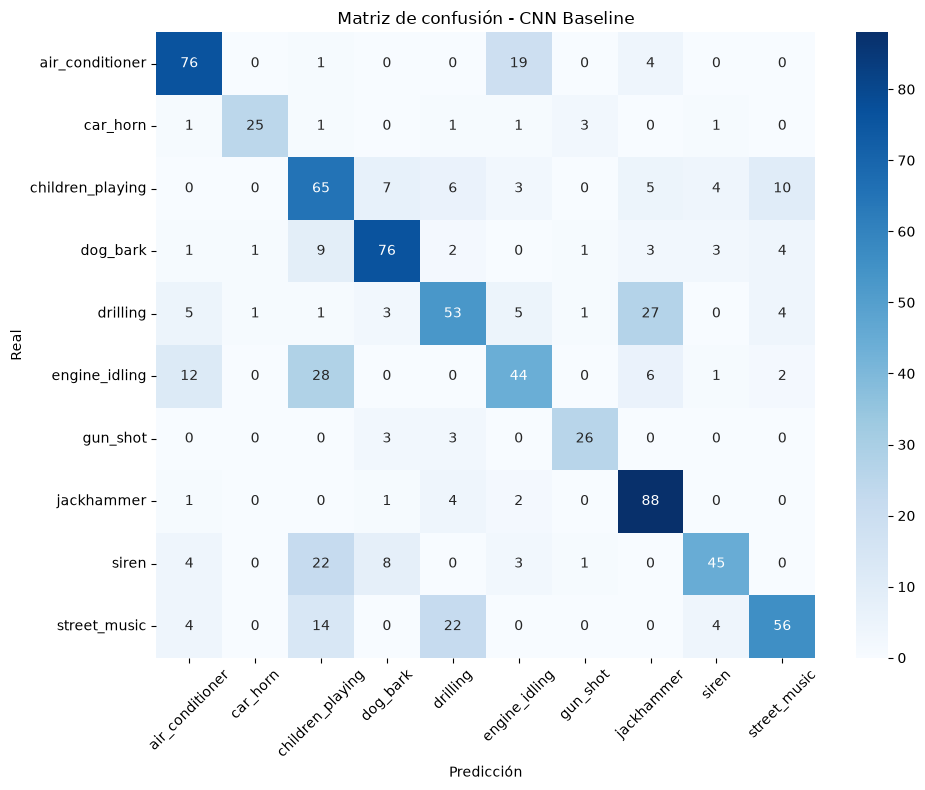

In [ ]:

# EVALUACIÓN DE LA CNN BASELINE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt



# Realiza predicciones sobre Fold 10

y_pred_prob = cnn_model.predict(
    X_test_mel,
    batch_size=32
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)



# Calcular métricas globales

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("RESULTADOS CNN BASELINE - FOLD 10")
print("-----------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# Reporte detallado por clase

print("\nREPORTE POR CLASE")
print("-----------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

#  Matriz de confusión

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusión - CNN Baseline")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### RESNET50

In [37]:
X_train_resnet = np.repeat(
    X_train_mel,
    3,
    axis=-1
)

X_val_resnet = np.repeat(
    X_val_mel,
    3,
    axis=-1
)

X_test_resnet = np.repeat(
    X_test_mel,
    3,
    axis=-1
)

print("Train:", X_train_resnet.shape)
print("Validation:", X_val_resnet.shape)
print("Test:", X_test_resnet.shape)

Train: (7079, 128, 173, 3)
Validation: (816, 128, 173, 3)
Test: (837, 128, 173, 3)


In [42]:

# CONViIERTE LOS ESPECTROGRAMAS A 3 CANALES


X_train_resnet = np.repeat(
    X_train_mel,
    3,
    axis=-1
)

X_val_resnet = np.repeat(
    X_val_mel,
    3,
    axis=-1
)

X_test_resnet = np.repeat(
    X_test_mel,
    3,
    axis=-1
)



#  CARGA RESNET50 PREENTRENADA

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 173, 3)
)


# Congelar las capas preentrenadas
base_model.trainable = False



# CONSTRUYE EL MODELO

resnet_model = models.Sequential([

    # ResNet50 preentrenada
    base_model,

    # Reducir las características obtenidas
    layers.GlobalAveragePooling2D(),

    # Capa de clasificación intermedia
    layers.Dense(
        256,
        activation="relu"
    ),

    # Reducir sobreajuste
    layers.Dropout(0.5),

    # Salida para las 10 clases
    layers.Dense(
        10,
        activation="softmax"
    )
])



# COMPILA EL MODELO


resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



# ARQUITECTURA

resnet_model.summary()



# MUESTRA DIMENSIONES DE LOS DATOS


print("Datos para ResNet50:")
print("Train:", X_train_resnet.shape)
print("Validation:", X_val_resnet.shape)
print("Test:", X_test_resnet.shape)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Datos para ResNet50:
Train: (7079, 128, 173, 3)
Validation: (816, 128, 173, 3)
Test: (837, 128, 173, 3)


In [43]:
BATCH_SIZE = 32
EPOCHS = 30

# Early Stopping


early_stopping_resnet = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)



# Guarda el mejor modelo


checkpoint_resnet = ModelCheckpoint(
    "resnet50_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)



# Entrena ResNet50


history_resnet = resnet_model.fit(
    X_train_resnet,
    y_train,
    validation_data=(
        X_val_resnet,
        y_val
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping_resnet,
        checkpoint_resnet
    ],
    verbose=1
)

Epoch 1/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.4656 - loss: 1.5790
Epoch 1: val_loss improved from None to 0.98825, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 161s 694ms/step - accuracy: 0.4656 - loss: 1.5790 - val_accuracy: 0.7083 - val_loss: 0.9882
Epoch 2/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.6730 - loss: 0.9818
Epoch 2: val_loss improved from 0.98825 to 0.85416, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 156s 701ms/step - accuracy: 0.6730 - loss: 0.9818 - val_accuracy: 0.7390 - val_loss: 0.8542
Epoch 3/30
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.7269 - loss: 0.8168
Epoch 3: val_loss improved from 0.85416 to 0.79258, saving model to resnet50_best.keras

Epoch 3: finished saving model to resnet50_best.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 147s 660ms/step - accuracy: 0.7269 - lo

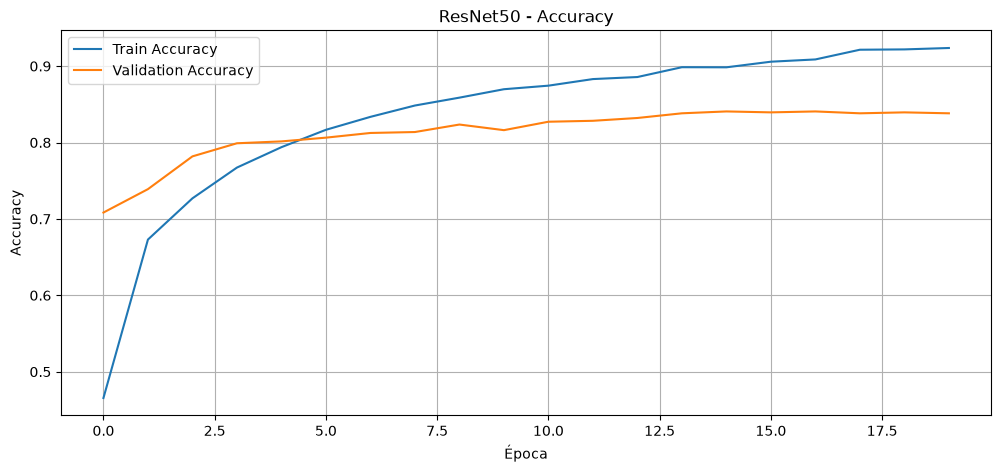

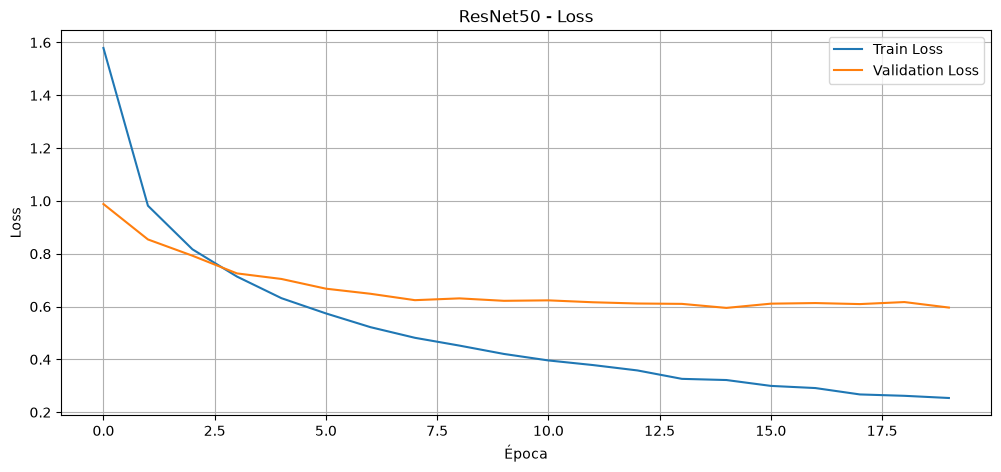

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(
    history_resnet.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_resnet.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 - Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    history_resnet.history["loss"],
    label="Train Loss"
)

plt.plot(
    history_resnet.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 - Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 578ms/step
RESULTADOS RESNET50 - FOLD 10
--------------------------------
Accuracy : 0.8184
Precision: 0.8290
Recall   : 0.8184
F1-score : 0.8160

REPORTE POR CLASE
-----------------
                  precision    recall  f1-score   support

 air_conditioner       0.87      0.71      0.78       100
        car_horn       0.89      0.52      0.65        33
children_playing       0.73      0.87      0.79       100
        dog_bark       0.90      0.72      0.80       100
        drilling       0.79      0.76      0.78       100
   engine_idling       0.83      0.78      0.81        93
        gun_shot       0.97      0.94      0.95        32
      jackhammer       0.80      1.00      0.89        96
           siren       0.93      0.86      0.89        83
    street_music       0.73      0.92      0.81       100

        accuracy                           0.82       837
       macro avg       0.84      0.81      0.82       837
    weighted avg       0.83   

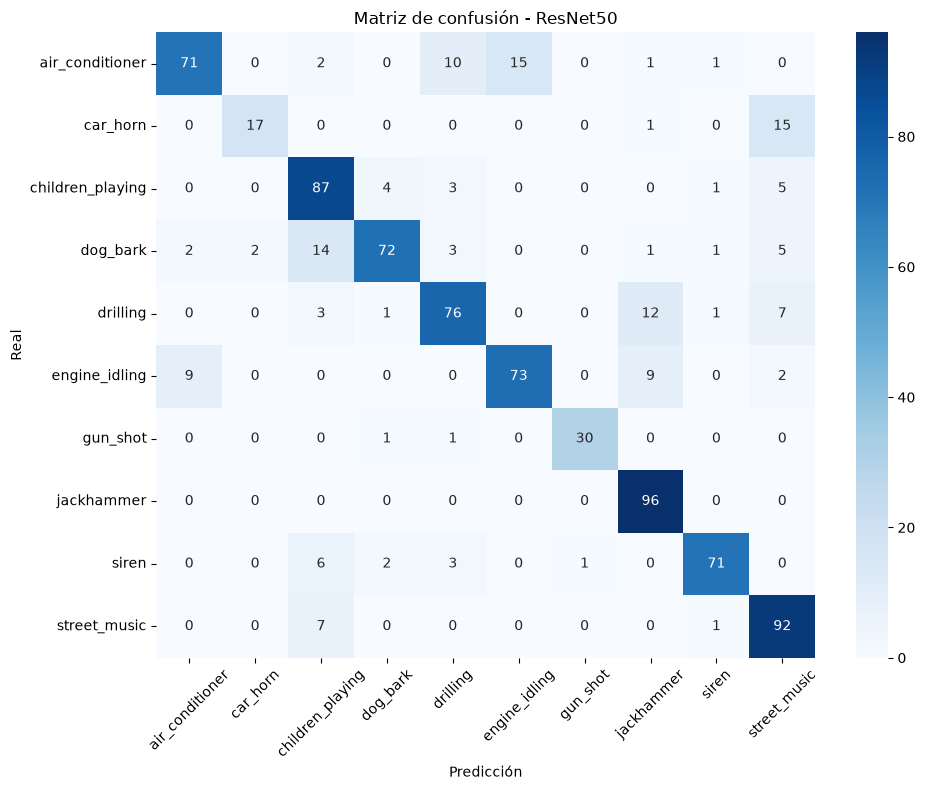

In [51]:


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)





y_pred_prob_resnet = resnet_model.predict(
    X_test_resnet,
    batch_size=32
)

y_pred_resnet = np.argmax(
    y_pred_prob_resnet,
    axis=1
)



accuracy_resnet = accuracy_score(
    y_test,
    y_pred_resnet
)

precision_resnet = precision_score(
    y_test,
    y_pred_resnet,
    average="weighted",
    zero_division=0
)

recall_resnet = recall_score(
    y_test,
    y_pred_resnet,
    average="weighted",
    zero_division=0
)

f1_resnet = f1_score(
    y_test,
    y_pred_resnet,
    average="weighted",
    zero_division=0
)




print("RESULTADOS RESNET50 - FOLD 10")
print("--------------------------------")
print(f"Accuracy : {accuracy_resnet:.4f}")
print(f"Precision: {precision_resnet:.4f}")
print(f"Recall   : {recall_resnet:.4f}")
print(f"F1-score : {f1_resnet:.4f}")




print("\nREPORTE POR CLASE")
print("-----------------")

print(
    classification_report(
        y_test,
        y_pred_resnet,
        target_names=class_names,
        zero_division=0
    )
)




cm_resnet = confusion_matrix(
    y_test,
    y_pred_resnet
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusión - ResNet50")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### COMPARATIVO

COMPARACIÓN DE MODELOS
----------------------


,Modelo,Accuracy,Precision,Recall,F1-score
0,CNN Baseline,0.6619,0.6765,0.6619,0.6604
1,ResNet50,0.8184,0.8290,0.8184,0.8160



Mejora de Accuracy: 15.65 puntos porcentuales
Mejora de F1-score: 15.56 puntos porcentuales


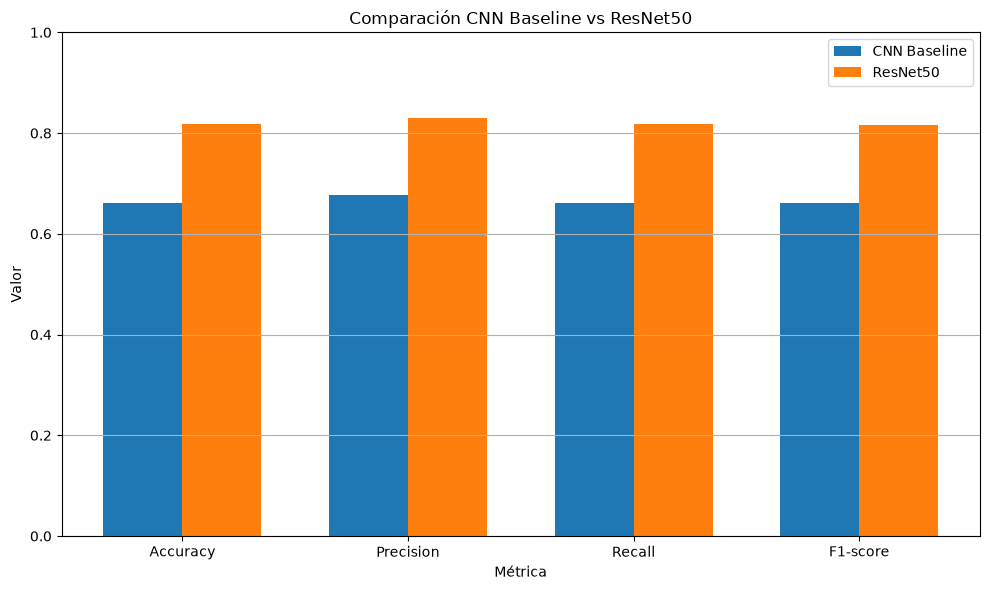

In [49]:

# Tabla de resultados

results = pd.DataFrame({
    "Modelo": [
        "CNN Baseline",
        "ResNet50"
    ],
    "Accuracy": [
        accuracy,
        accuracy_resnet
    ],
    "Precision": [
        precision,
        precision_resnet
    ],
    "Recall": [
        recall,
        recall_resnet
    ],
    "F1-score": [
        f1,
        f1_resnet
    ]
})



# Resultados


print("COMPARACIÓN DE MODELOS")
print("----------------------")

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)



# Calcula mejora de ResNet50


accuracy_improvement = (
    accuracy_resnet - accuracy
) * 100

f1_improvement = (
    f1_resnet - f1
) * 100

print(
    f"\nMejora de Accuracy: "
    f"{accuracy_improvement:.2f} puntos porcentuales"
)

print(
    f"Mejora de F1-score: "
    f"{f1_improvement:.2f} puntos porcentuales"
)



# 4. Gráfica comparativa


metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

cnn_values = [
    accuracy,
    precision,
    recall,
    f1
]

resnet_values = [
    accuracy_resnet,
    precision_resnet,
    recall_resnet,
    f1_resnet
]


x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    cnn_values,
    width,
    label="CNN Baseline"
)

plt.bar(
    x + width / 2,
    resnet_values,
    width,
    label="ResNet50"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Valor")
plt.xlabel("Métrica")
plt.title("Comparación CNN Baseline vs ResNet50")

plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

RESULTADOS FINALES


,Modelo,Accuracy,Precision,Recall,F1-score
0,CNN Baseline,66.19%,67.65%,66.19%,66.04%
1,ResNet50,81.84%,82.90%,81.84%,81.60%


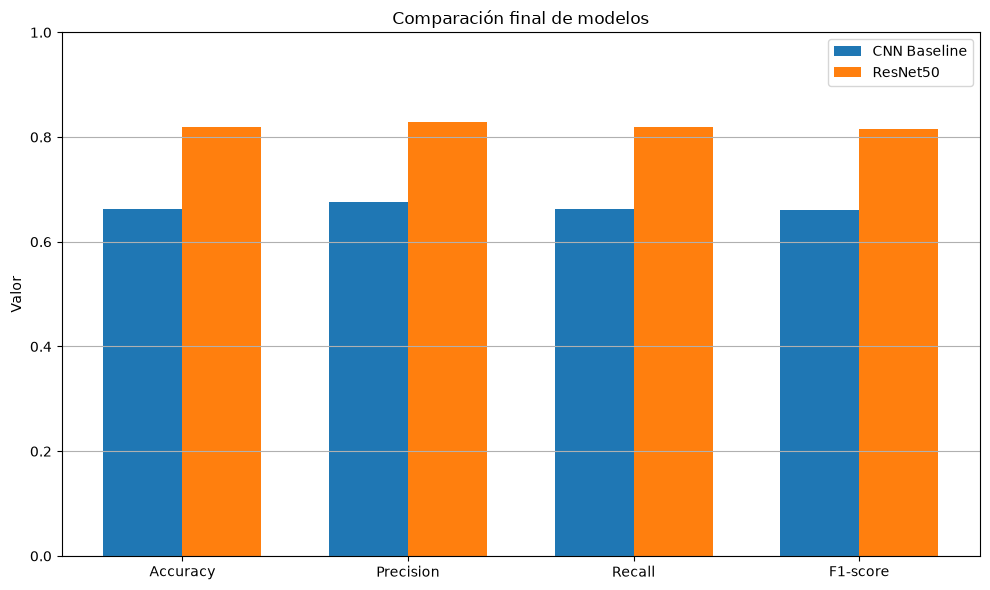

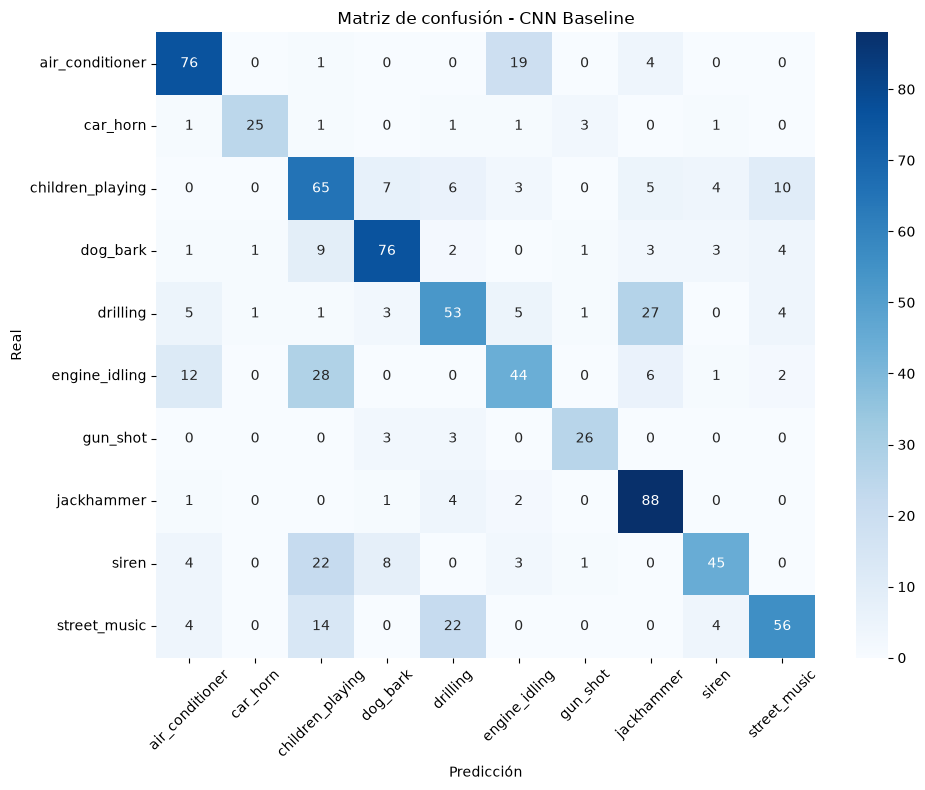

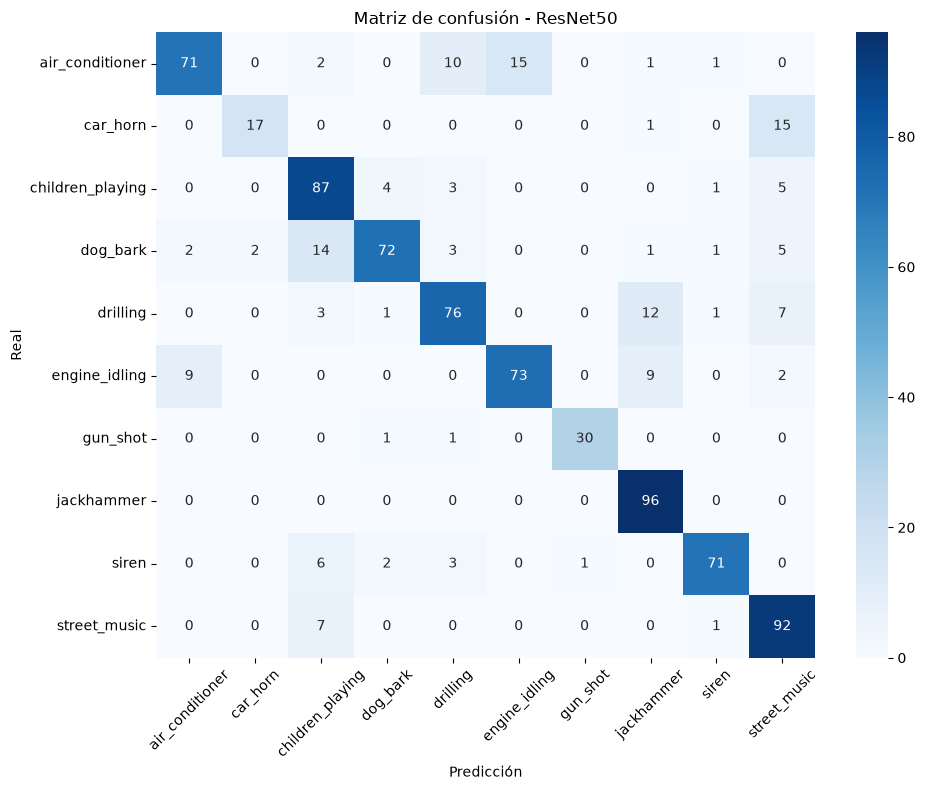

In [ ]:
results_final = pd.DataFrame({
    "Modelo": [
        "CNN Baseline",
        "ResNet50"
    ],
    "Accuracy": [
        accuracy,
        accuracy_resnet
    ],
    "Precision": [
        precision,
        precision_resnet
    ],
    "Recall": [
        recall,
        recall_resnet
    ],
    "F1-score": [
        f1,
        f1_resnet
    ]
})

print("RESULTADOS FINALES")
print("===================")

display(
    results_final.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-score": "{:.2%}"
    })
)




results_final.to_csv(
    "resultados_modelos.csv",
    index=False
)




metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

cnn_values = [
    accuracy,
    precision,
    recall,
    f1
]

resnet_values = [
    accuracy_resnet,
    precision_resnet,
    recall_resnet,
    f1_resnet
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    cnn_values,
    width,
    label="CNN Baseline"
)

plt.bar(
    x + width / 2,
    resnet_values,
    width,
    label="ResNet50"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Valor")
plt.title("Comparación final de modelos")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "comparacion_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusión - CNN Baseline")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "matriz_confusion_cnn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()




plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusión - ResNet50")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "matriz_confusion_resnet50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()